<div style="background-color:#111827;
padding:25px;
border-left:8px solid #F59E0B;
border-radius:10px;
margin-bottom:20px;">

<h1 style="color:white;
font-size:34px;
margin:0;">
Detección de Fraudes Bancarios
</h1>

<p style="color:#D1D5DB;
font-size:16px;
margin-top:10px;">
Regresión Logistica como Benchmark y prueba de LightGBM.
</p>

</div>

El objetivo es construir un modelo que detecte transacciones fraudulentas, priorizando capturar la mayor cantidad posible (Recall) aunque eso signifique tener algunas falsas alarmas.

Flujo de tu trabajo:

- Limpieza: Datos con valores nulos e incorrectos (edades con errores, textos).  

- EDA: De variables más importantes.  

- Ingeniería: Creación de nuevas variables como Saldo.Utilizado y Riesgo.Total para mejorar la información.

- Modelado: Dos enfoques. Un modelo lineal (Regresión Logística) usado en principio como benchmark o modelo a superar y uno de boosting (LightGBM).  

<h2 style="
background-color:#111827;
color:white;
padding:14px;
border-radius:10px;
border-left:6px solid #F59E0B;
font-size:28px;
">
Índice
</h2>

<div style="
background-color:#1F2937;
padding:20px;
border-radius:10px;
margin-top:10px;
color:#E5E7EB;
font-size:16px;
line-height:2;
">

<a href="#0" style="color:#D1D5DB; text-decoration:none;">
1. Preparación y limpieza de los datos
</a>
<br>

<a href="#1" style="color:#D1D5DB; text-decoration:none;">
2. Análisis exploratorio de datos (EDA)
</a>
<br>

<a href="#2" style="color:#D1D5DB; text-decoration:none;">
3. Modelado y evaluación
</a>
<br>

<a href="#4" style="color:#D1D5DB; text-decoration:none;">
4. Conclusiones
</a>

</div>

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">01</span>
Preparación y limpieza de los datos
</div>
<a id="0"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from great_tables import GT

import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Borrar warnings

In [2]:
df = pd.read_csv("Fraude_Credito_2.csv")

In [3]:
df.columns=["Edad", "Monto", "Saldo", "Trans.Hoy", "Trans.Extranjera", "Hora", "Fraude Previo", "Dist.Comercio", "Riesgo.Comercio", "Fraude"]

In [4]:
GT(df.head(5))

Edad,Monto,Saldo,Trans.Hoy,Trans.Extranjera,Hora,Fraude Previo,Dist.Comercio,Riesgo.Comercio,Fraude
41.0,2453.81,12686.5,21.0,0.0,9.0,0.0,2438.2,5.2,0
49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
61.0,12914.13,2013.73,34.0,0.0,,0.0,4366.7,9.7,1


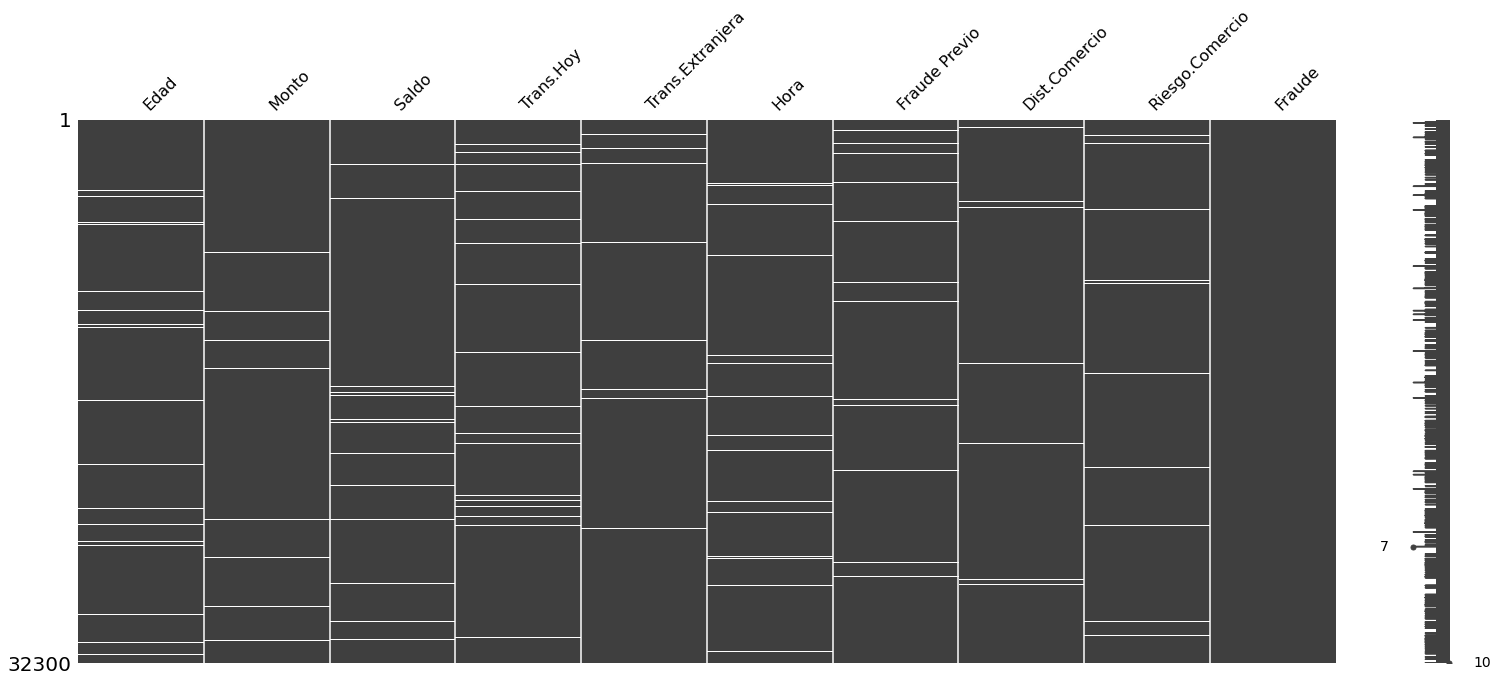

In [5]:
import missingno as msno

msno.matrix(df)
plt.show()

In [6]:
(df.describe()
      .T
      .style
      .background_gradient(cmap='gist_gray')
      .format('{:.2f}'))

,count,mean,std,min,25%,50%,75%,max
Monto,31653.00,7471.58,4324.13,1.07,3723.40,7475.07,11199.09,14999.71
Saldo,31655.00,25020.77,14423.75,-99999.00,12510.30,25050.49,37530.21,49998.90
Trans.Hoy,31654.00,24.92,14.15,1.00,13.00,25.00,37.00,49.00
Trans.Extranjera,31649.00,0.15,0.35,0.00,0.00,0.00,0.00,1.00
Hora,31657.00,11.47,6.92,0.00,5.00,11.00,17.00,28.00
Fraude Previo,31654.00,0.08,0.27,0.00,0.00,0.00,0.00,1.00
Dist.Comercio,31657.00,2500.27,1444.74,0.10,1250.00,2507.00,3741.30,4999.80
Riesgo.Comercio,31656.00,5.51,2.59,1.00,3.30,5.50,7.80,15.00
Fraude,32300.00,0.48,0.50,0.00,0.00,0.00,1.00,1.00


In [7]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Edad              31656 non-null  object 
 1   Monto             31653 non-null  float64
 2   Saldo             31655 non-null  float64
 3   Trans.Hoy         31654 non-null  float64
 4   Trans.Extranjera  31649 non-null  float64
 5   Hora              31657 non-null  float64
 6   Fraude Previo     31654 non-null  float64
 7   Dist.Comercio     31657 non-null  float64
 8   Riesgo.Comercio   31656 non-null  float64
 9   Fraude            32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)

In [8]:
df["Edad"].value_counts(5)

50.0        0.019206
62.0        0.018701
51.0        0.018638
72.0        0.018480
34.0        0.018417
              ...   
nan_err     0.000032
22.0_err    0.000032
74.0_err    0.000032
-10.0       0.000032
63.0_err    0.000032
Name: Edad, Length: 103, dtype: float64

In [9]:
# Reemplazo el valor incorrecto por el correcto
df["Edad"] = df["Edad"].replace({-10.0: 10, "-10.0": 10})

In [10]:
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce") # Saca todos los textos

In [11]:
df["Monto"].value_counts()

3046.43     3
3363.42     3
1289.55     3
8181.60     3
9669.84     3
           ..
7865.35     1
5497.52     1
11117.98    1
7787.55     1
11266.58    1
Name: Monto, Length: 31028, dtype: int64

In [12]:
df.isnull().sum()

Edad                724
Monto               647
Saldo               645
Trans.Hoy           646
Trans.Extranjera    651
Hora                643
Fraude Previo       646
Dist.Comercio       643
Riesgo.Comercio     644
Fraude                0
dtype: int64

In [13]:
df["Hora"].value_counts(bins=8).head(10)

(-0.029, 3.5]    5302
(10.5, 14.0]     5253
(3.5, 7.0]       5229
(17.5, 21.0]     5203
(14.0, 17.5]     4044
(7.0, 10.5]      4021
(21.0, 24.5]     2604
(24.5, 28.0]        1
Name: Hora, dtype: int64

In [14]:
# Reemplazo el valor incorrecto por el correcto
df["Hora"] = df["Hora"].replace({28.0: 0.0, "28.0": 0.0})

Tratamiento de valores nulos:

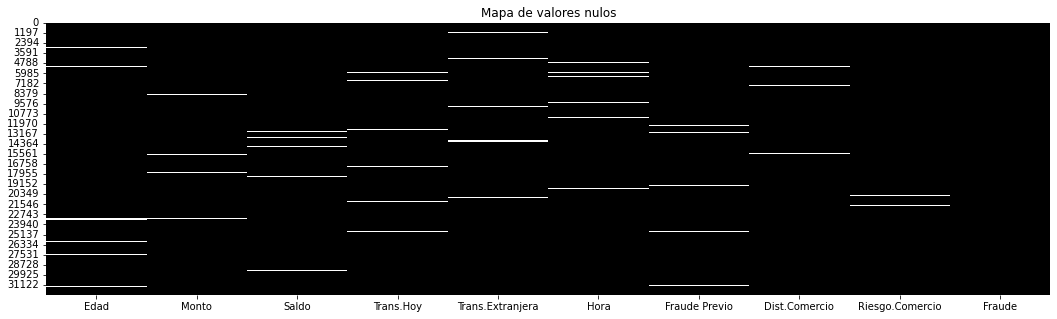

In [15]:
plt.figure(figsize=(18,5))
sns.heatmap(df.isnull(), cbar=False, cmap="gist_gray")
plt.title("Mapa de valores nulos")
plt.show()


In [16]:
df['Edad'] = df['Edad'].fillna(df['Edad'].mean()) # Reemplazo por la media porque no distorsiona y es el valor mas tipico del grupo.

In [17]:
df['Monto'] = df['Monto'].fillna(df['Monto'].median()) # Reemplazo por la mediana, porque puede tener montos altos o bajos, no distorsionan el valor central.

In [18]:
df['Saldo'] = df['Saldo'].fillna(df['Saldo'].median()) # Uso la mediana por el mismo motivo que en el campo "Monto".

In [19]:
df['Trans.Hoy'] = df['Trans.Hoy'].fillna(df['Trans.Hoy'].median())

In [20]:
df['Trans.Extranjera'] = df['Trans.Extranjera'].fillna(0) # Porque generalmente son muy pocas transacciones extrangeras.

In [21]:
df['Hora'] = df['Hora'].fillna(df['Hora'].median())

In [22]:
df['Fraude Previo'] = df['Fraude Previo'].fillna(0) # Al no tener mas datos, asumo que no hubo info sobre fraudes previos.

In [23]:
df['Dist.Comercio'] = df['Dist.Comercio'].fillna(df['Dist.Comercio'].median()) # Mediana mas robusta ante outliers que pueda tener.

In [24]:
df['Riesgo.Comercio'] = df['Riesgo.Comercio'].fillna(df['Riesgo.Comercio'].median())

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">02</span>
Análisis exploratorio de datos (EDA)
</div>
<a id="1"></a>

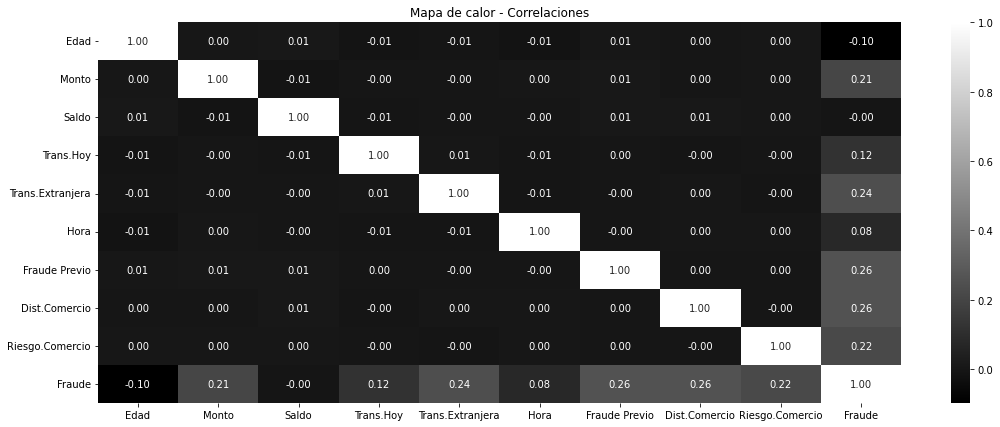

In [25]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='gist_gray')
plt.title('Mapa de calor - Correlaciones')
plt.show()

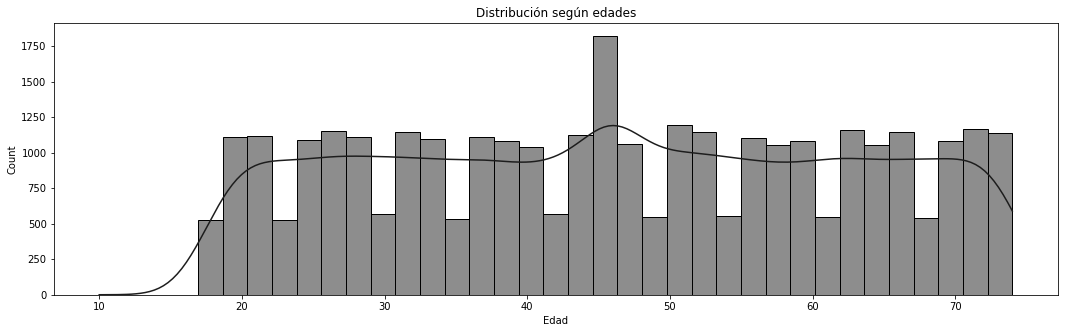

In [26]:
plt.figure(figsize=(18,5))
sns.histplot(df['Edad'],kde=True, color="#1d1d1d")
plt.title('Distribución según edades')
plt.show()

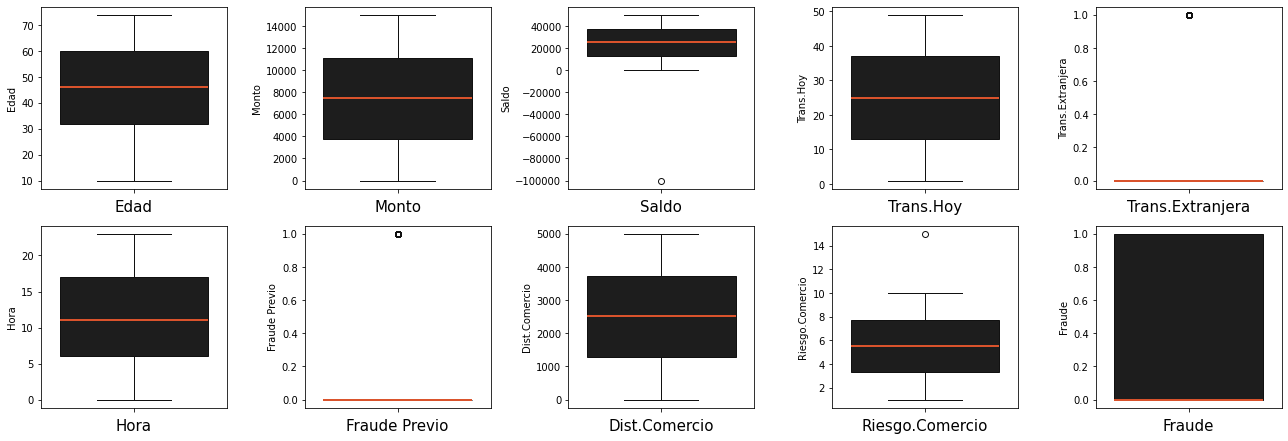

In [27]:
plt.figure(figsize = (18, 15))
plotnumber = 1

for col in df.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(df[col], color="#1d1d1d", medianprops={"color": "#da532c", "linewidth": 2})
        plt.xlabel(col, fontsize = 15)
    
    plotnumber += 1
plt.tight_layout()
plt.show()

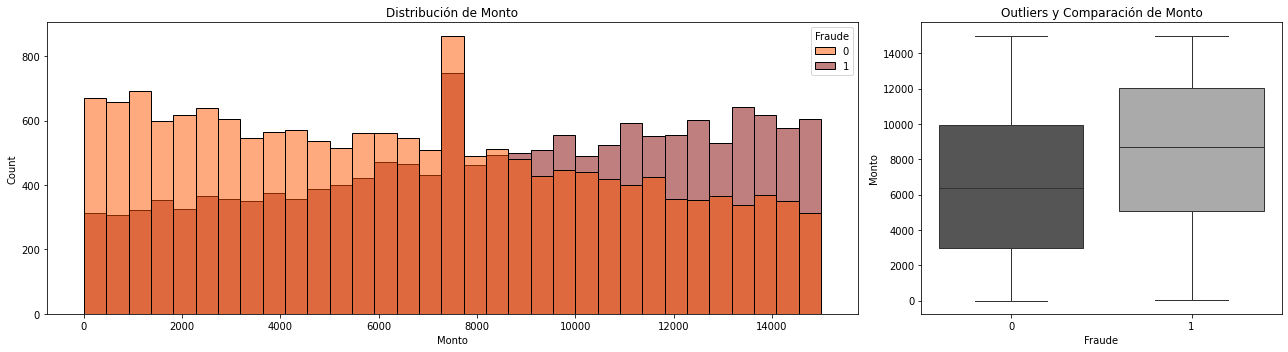

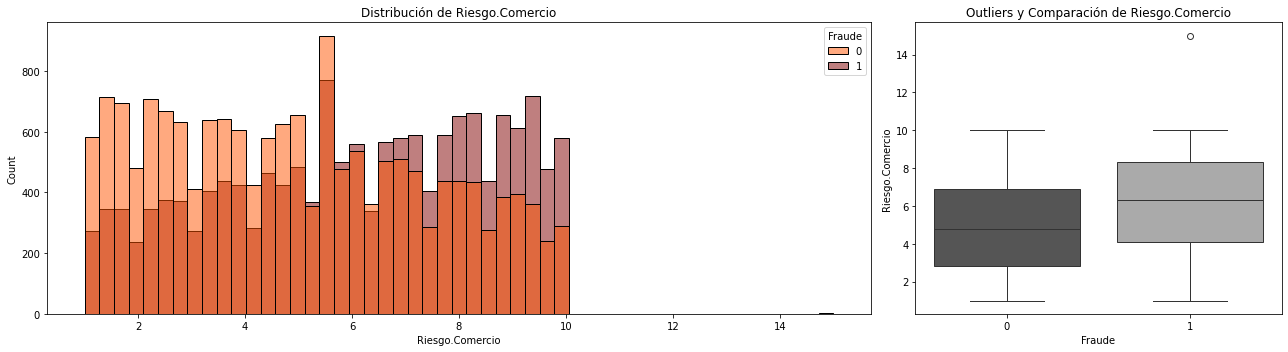

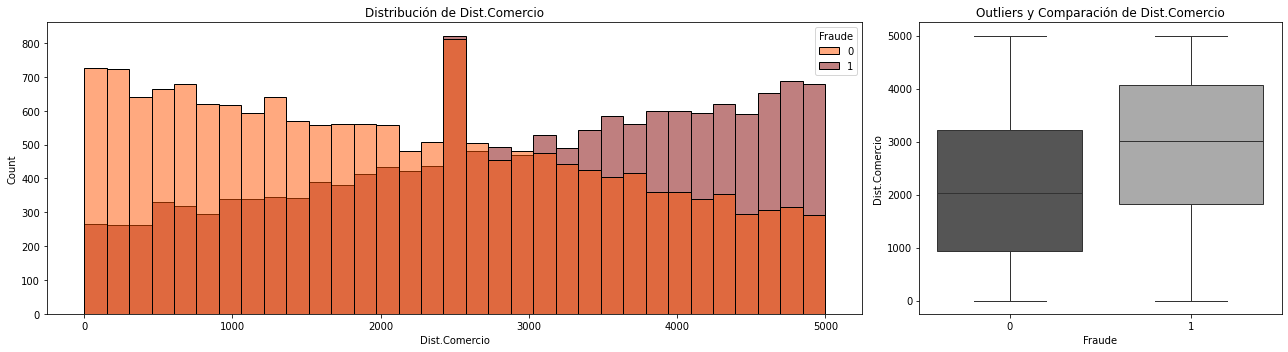

In [28]:
def plot_variable_analisis(df, col):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [0.9, 0.4]})
    
    # Histograma para ver la forma de los datos
    sns.histplot(data=df, x=col, hue='Fraude', kde=False, ax=ax_hist, palette='gist_heat_r')
    ax_hist.set_title(f'Distribución de {col}')
    
    # Boxplot para ver los outliers y la diferencia
    sns.boxplot(data=df, x='Fraude', y=col, ax=ax_box, palette='gist_gray')
    ax_box.set_title(f'Outliers y Comparación de {col}')
    
    plt.tight_layout()
    plt.show()

# Graficos a mostrar...
plot_variable_analisis(df, 'Monto')
plot_variable_analisis(df, 'Riesgo.Comercio')
plot_variable_analisis(df, 'Dist.Comercio')

In [29]:
print('Interpretación: Lo gris es <no fraude>, lo verde claro es <fraude> y lo que coincide o se solapa entre los dos es verde oscuro')

Interpretación: Lo gris es <no fraude>, lo verde claro es <fraude> y lo que coincide o se solapa entre los dos es verde oscuro


Lo gris es "no fraude", lo verde claro es fraude y lo que coincide o se solapa entre los dos es verde oscuro.

1. Monto de la transacción
En cuanto al monto de las transacciones, se observa que los casos de fraude presentan una mediana superior a la de los casos no fraudulentos. Los bigotes superior e inferior son similares en ambas clasificaciones.

**Conclusión:** Los montos fraudulentos tienden a ser más altos en su valor central, pero la dispersión general es parecida entre ambos grupos.

2. Riesgo del comercio
En la variable de riesgo del comercio, los fraudes muestran una mediana más elevada. Además, el 50% central de los datos de fraude se ubica en un rango que alcanza prácticamente el tercer cuartil del grupo de no fraudes.

**Conclusión:** Los comercios con mayor riesgo están asociados a una mayor incidencia de fraudes.

3. Distancia al comercio
El comportamiento de la distancia al comercio es similar: la mediana de los fraudes es más alta y se aproxima al tercer cuartil de los casos no fraudulentos.

**Conclusión:** Las transacciones fraudulentas tienden a realizarse a mayores distancias del lugar habitual del cliente.

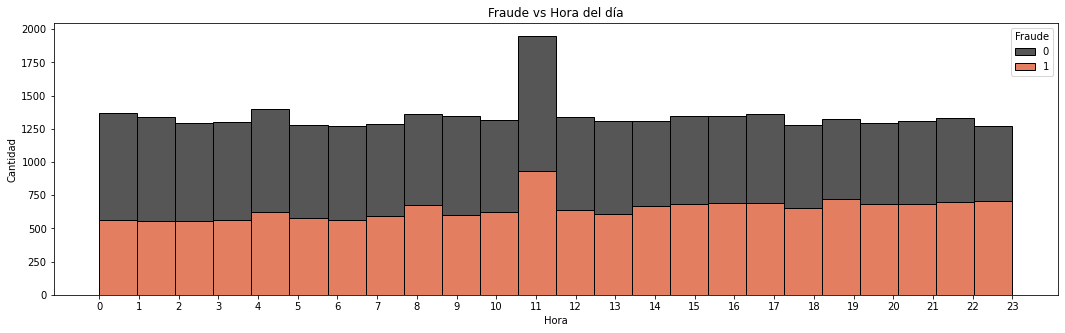

In [30]:
plt.figure(figsize=(18, 5))
sns.histplot(data=df, x='Hora', hue='Fraude', bins=24, multiple='stack', 
             palette={0: '#1d1d1d', 1: '#da532c'})
plt.title('Fraude vs Hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad')
plt.xticks(range(0, 24))
plt.show()

Con este grafico se ve si hay horas más peligrosas para el fraude. En este caso el horario mas afectado es el de las 11 horas, momento en el cual tambien se tiene un pico de transacciones legales.

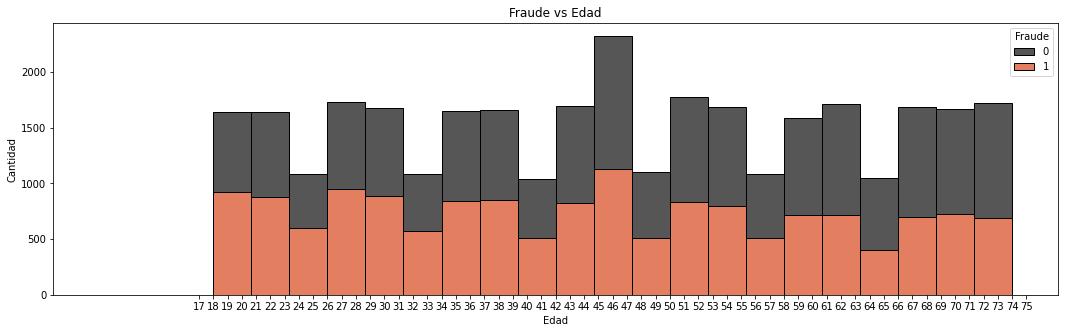

In [31]:
plt.figure(figsize=(18, 5))
sns.histplot(data=df, x='Edad', hue='Fraude', bins=24, multiple='stack', 
             palette={0: '#1d1d1d', 1: '#da532c'})
plt.title('Fraude vs Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.xticks(range(17, 76))
plt.show()

In [32]:
df['Fraude'].value_counts(normalize=True)

0    0.518266
1    0.481734
Name: Fraude, dtype: float64

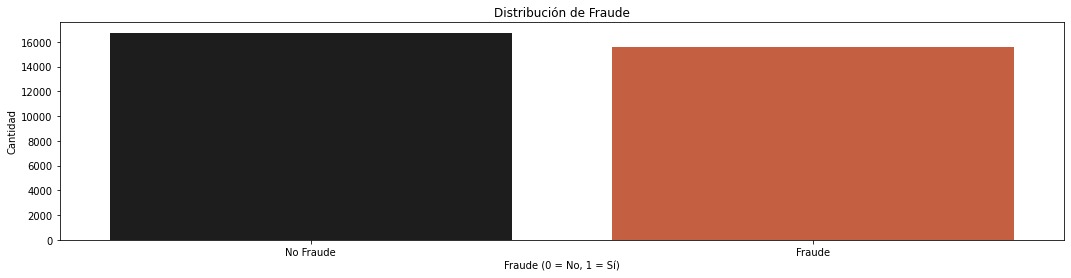

In [33]:
plt.figure(figsize=(18, 4))
sns.countplot(data=df, x='Fraude', palette=['#1d1d1d', '#da532c'])
plt.title('Distribución de Fraude')
plt.xlabel('Fraude (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.xticks([0, 1], ['No Fraude', 'Fraude'])
plt.show()

#### INGENIERIA DE CARACTERISTICAS

In [34]:
df['Saldo.Utilizado'] = df['Monto'] / (df['Saldo'] + 1) # Proporcion del saldo usado en la operación.
df['Sdo.Restante'] = df['Saldo'] - df['Monto'] # Cuanto queda luego de la operación.
#df['Op.Nocturna'] = ((df['Hora'] >= 0) & (df['Hora'] <= 6)).astype(int) # Operaciones entre las 0 y 6 de la mañana. (No usado porque no mejora nada el modelo)
df['Riesgo.Total'] = (df['Riesgo.Comercio']*(df['Fraude Previo'] + 1)) # Para ver si se da la convinacion de comercio riesgoso con cliente riesgoso.
df['Cl.AltoRiesgo'] = ((df['Fraude Previo'] == 1) & (df['Trans.Extranjera'] == 1)).astype(int) # Nuevo campo donde se ponen estos clientes riesgosos
#df['Monto_x_Riesgo'] = (df['Monto'] * df['Riesgo.Comercio']) # Interacción entre monto y el riesgo del comercio. (No usado porque no mejora nada el modelo)

#df['Grupo_Edad'] = pd.cut(df['Edad'],bins=[18,30,45,60,100]) # Separar por edades. (No usado porque no mejora nada el modelo)
#df['Franja_Horaria'] = pd.cut(df['Hora'], bins=[0,6,12,18,24]) # Separar por horas. (No usado porque no mejora nada el modelo)

df['Monto_Log'] = np.log1p(df['Monto']) # Logaritmo natural del monto, reduce la influencia desproporcionada de montos extremos.

In [35]:
df = df.round(2) # Solo 2 decimales en cada campo.

In [36]:
GT(df.head(5))

Edad,Monto,Saldo,Trans.Hoy,Trans.Extranjera,Hora,Fraude Previo,Dist.Comercio,Riesgo.Comercio,Fraude,Saldo.Utilizado,Sdo.Restante,Riesgo.Total,Cl.AltoRiesgo,Monto_Log
41.0,2453.81,12686.5,21.0,0.0,9.0,0.0,2438.2,5.2,0,0.19,10232.69,5.2,0,7.81
49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1,0.04,34762.9,8.4,0,7.36
38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0,0.64,8398.22,3.7,0,9.61
38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1,0.26,28658.85,5.5,0,9.2
61.0,12914.13,2013.73,34.0,0.0,11.0,0.0,4366.7,9.7,1,6.41,-10900.4,9.7,0,9.47


<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">03</span>
Modelado y evaluación
</div>
<a id="2"></a>

In [37]:
# SPLIT (único, compartido por los 2 modelos)
from sklearn.model_selection import train_test_split

X = df.drop("Fraude", axis=1)
y = df["Fraude"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y # Las proporciones se mantienen en ambos conjuntos. Tanto train como test tendrian similares cantidades de ambas clases.
)

### ▣ Regresion Logistica

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, f1_score, confusion_matrix

La regresión logística es sensible a la escala de las variables predictoras. En este dataset, columnas como Monto (con valores en miles) y Hora (rango 0-23) presentan escalas muy diferentes. Si no se estandarizan, el modelo podría asignar una importancia desmedida a variables con valores numéricamente más altos, no porque sean más relevantes, sino simplemente por su magnitud. Para evitar este sesgo, se aplica StandardScaler, que centra los datos en media cero y los ajusta a desviación estándar unitaria, asegurando que todas las variables contribuyan en igualdad de condiciones.

In [39]:
# Escaladar las variables.
scaler = StandardScaler()

In [40]:
X_train_scaled = scaler.fit_transform(X_train) # El fit se hace SOLO en el train para aprender la media y desviación.
X_test_scaled = scaler.transform(X_test) # El transform se hace en el test usando lo aprendido del train

In [41]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42) #Entrenar el modelo con los datos ESCALADOS
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [42]:
y_pred = lr.predict(X_test_scaled) # Predecir.

In [43]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

threshold = 0.5 # Detectara más fraudes
y_pred = (y_prob >= threshold).astype(int)

In [44]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

In [45]:
print("═" * 55)
print("---------- Métricas de Desempeño ----------")
print("═" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | ({accuracy:.2%}) → Aciertos totales")
print(f"Recall:   {recall_score(y_test, y_pred):.4f} | ({recall:.2%}) → Fraudes detectados")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f} | ({auc:.2%}) → Capacidad discriminativa")
print(f"F1 Score:      {f1:.4f}")
print()
print("═" * 55)
print("-----------Matriz de confusión:-----------\n", confusion_matrix(y_test, y_pred))
print("═" * 55)

cm = confusion_matrix(y_test, y_pred)

print(f"  ❑ El modelo detectó el {recall:.1%} de los fraudes reales.")
print(f"  ❑ Tuvo {confusion_matrix(y_test, y_pred)[0,1]} falsas alarmas (buenos marcados como malos).")
print(f"  ❑ Perdió {confusion_matrix(y_test, y_pred)[1,0]} fraudes (no los detectó).")

═══════════════════════════════════════════════════════
---------- Métricas de Desempeño ----------
═══════════════════════════════════════════════════════
Accuracy: 0.7463 | (74.63%) → Aciertos totales
Recall:   0.7294 | (72.94%) → Fraudes detectados
AUC-ROC:  0.8254 | (82.54%) → Capacidad discriminativa
F1 Score:      0.7348

═══════════════════════════════════════════════════════
-----------Matriz de confusión:-----------
 [[3827 1195]
 [1263 3405]]
═══════════════════════════════════════════════════════
  ❑ El modelo detectó el 72.9% de los fraudes reales.
  ❑ Tuvo 1195 falsas alarmas (buenos marcados como malos).
  ❑ Perdió 1263 fraudes (no los detectó).


In [46]:
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr.coef_[0]
})

coeficientes.sort_values(
    by='Coeficiente',
    key=abs,
    ascending=False
)

,Variable,Coeficiente
6,Fraude Previo,0.882757
7,Dist.Comercio,0.757754
4,Trans.Extranjera,0.709749
8,Riesgo.Comercio,0.583666
1,Monto,0.569113
3,Trans.Hoy,0.361135
0,Edad,-0.280195
5,Hora,0.228295
10,Sdo.Restante,-0.095348
12,Cl.AltoRiesgo,0.082138


### ▣ LightGBM

In [47]:
import lightgbm as lgb # Importo la libreria lightGMB.
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [48]:
# Parámetros de LightGBM
params = {
    'objective': 'binary',            # Clasificación binaria
    'metric': 'auc',                  # Métrica de evaluación: (AUC)
    'boosting_type': 'gbdt',          # Tipo de algoritmo boosting va a utilizar el modelo para construir los árboles (dart, goss, rf)
    'n_estimators': 300,              # Número de árboles
    'learning_rate': 0.05,            # Tasa de aprendizaje, hasta 0,05 el aprendizaje es más suave, mejor generalización
    'num_leaves': 45,                 # Máximo número de hojas por árbol, más hojas mayor capacidad de aprendizaje pero más riesgo de sobreajuste
    'verbose': -1,                    # Suprimir mensajes de salida, silencia prácticamente toda la salida informativa del proceso.
    'n_jobs': -1,                     # Usar todos los núcleos de CPU disponibles
    'seed': 42                        # Aleatoriedad, fijada en el 42.
}

In [49]:
# Inicializo y entreno el modelo
modelo_lgbm = lgb.LGBMClassifier(**params)

# early_stopping_rounds es para detener el entrenamiento si la métrica no mejora
# Esto requiere un conjunto de validación separado (eval_set)
modelo_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],  # Conjunto para monitorear el rendimiento
    eval_metric='auc',
    callbacks=[lgb.early_stopping(10, verbose=False)] # Detener si no mejora en 10 rondas
)

LGBMClassifier(learning_rate=0.05, metric='auc', n_estimators=300, n_jobs=-1,
               num_leaves=45, objective='binary', seed=42, verbose=-1)

In [50]:
y_pred = modelo_lgbm.predict(X_test) # Predicción de clases (necesaria para Exactitud)

In [51]:
y_proba = modelo_lgbm.predict_proba(X_test)[:, 1] # Predicción de probabilidades (necesito para calcular AUC)

In [52]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

In [53]:
print("═" * 55)
print("---------- Métricas de Desempeño ----------")
print("═" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | ({accuracy:.2%}) → Aciertos totales")
print(f"Recall:   {recall_score(y_test, y_pred):.4f} | ({recall:.2%}) → Fraudes detectados")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba):.4f} | ({auc:.2%}) → Capacidad discriminativa")
print(f"F1 Score:      {f1:.4f}")
print()
print("═" * 55)
print("-----------Matriz de confusión:-----------\n", confusion_matrix(y_test, y_pred))
print("═" * 55)

cm = confusion_matrix(y_test, y_pred)

print(f"  ❑ El modelo detectó el {recall:.1%} de los fraudes reales.")
print(f"  ❑ Tuvo {confusion_matrix(y_test, y_pred)[0,1]} falsas alarmas (buenos marcados como malos).")
print(f"  ❑ Perdió {confusion_matrix(y_test, y_pred)[1,0]} fraudes (no los detectó).")

═══════════════════════════════════════════════════════
---------- Métricas de Desempeño ----------
═══════════════════════════════════════════════════════
Accuracy: 0.7419 | (74.19%) → Aciertos totales
Recall:   0.7136 | (71.36%) → Fraudes detectados
AUC-ROC:  0.8203 | (82.03%) → Capacidad discriminativa
F1 Score:      0.7271

═══════════════════════════════════════════════════════
-----------Matriz de confusión:-----------
 [[3858 1164]
 [1337 3331]]
═══════════════════════════════════════════════════════
  ❑ El modelo detectó el 71.4% de los fraudes reales.
  ❑ Tuvo 1164 falsas alarmas (buenos marcados como malos).
  ❑ Perdió 1337 fraudes (no los detectó).


In [54]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_lgbm.feature_importances_
}).sort_values(
    'Importancia',
    ascending=False
)
importancias

,Variable,Importancia
7,Dist.Comercio,667
3,Trans.Hoy,552
0,Edad,478
1,Monto,476
8,Riesgo.Comercio,375
5,Hora,372
13,Monto_Log,218
2,Saldo,201
11,Riesgo.Total,200
9,Saldo.Utilizado,193


<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">04</span>
Conclusiones
</div>
<a id="3"></a>

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC
0,Regresión Logística,0.7463,0.7402,0.7294,0.7348,0.8254
1,LightGBM,0.7419,0.7410,0.7136,0.7271,0.8203


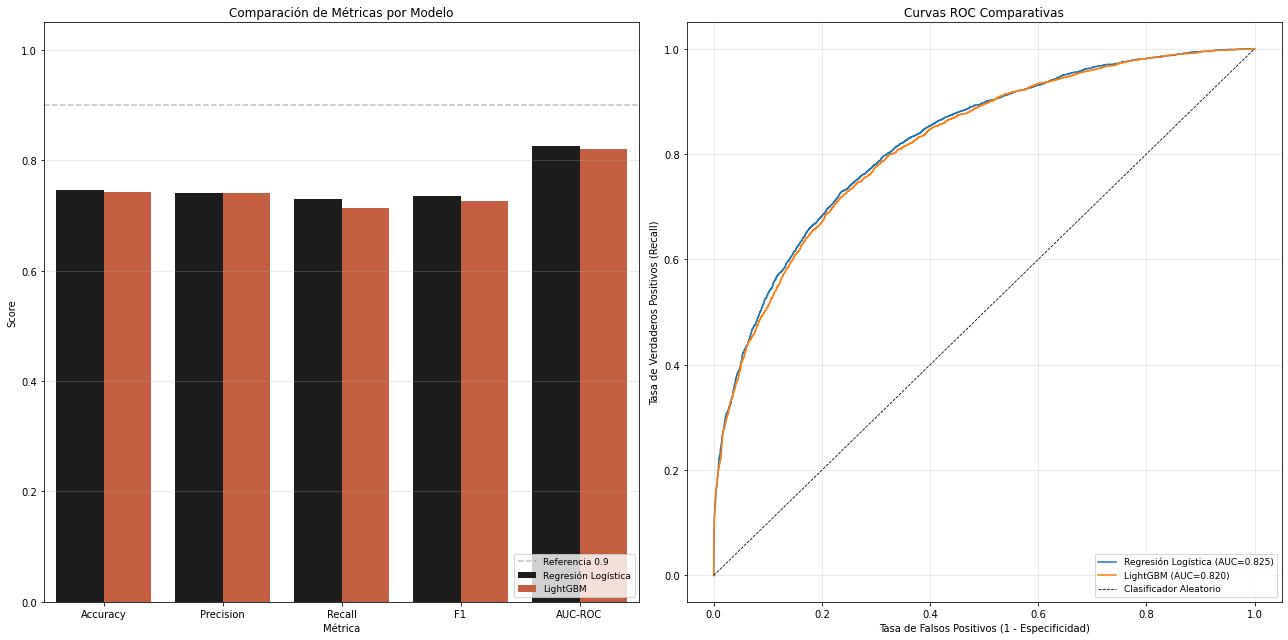

In [55]:
# Estructura de resultados con los modelos ya entrenados
from sklearn.metrics import roc_curve, precision_score

resultados = [
    {
        "Modelo":    "Regresión Logística",
        "_y_prob":   lr.predict_proba(X_test_scaled)[:, 1],
        "_y_pred":   (lr.predict_proba(X_test_scaled)[:, 1] >= threshold).astype(int),
    },
    {
        "Modelo":    "LightGBM",
        "_y_prob":   modelo_lgbm.predict_proba(X_test)[:, 1],
        "_y_pred":   modelo_lgbm.predict(X_test),
    },
]

# Métricas y armar df
for r in resultados:
    r["Accuracy"]  = accuracy_score(y_test, r["_y_pred"])
    r["Precision"] = precision_score(y_test, r["_y_pred"])
    r["Recall"]    = recall_score(y_test, r["_y_pred"])
    r["F1"]        = f1_score(y_test, r["_y_pred"])
    r["AUC-ROC"]   = roc_auc_score(y_test, r["_y_prob"])

metricas_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
df_resultados = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados])
    .sort_values("AUC-ROC", ascending=False)
    .reset_index(drop=True)
)

display(df_resultados.style.format({c: "{:.4f}" for c in metricas_cols}).highlight_max(subset=metricas_cols, color="#c6efce"))

# Gráfico de barras + Curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Barras
df_melt = df_resultados.melt(id_vars="Modelo", value_vars=metricas_cols,
                              var_name="Métrica", value_name="Score")
sns.barplot(data=df_melt, x="Métrica", y="Score", hue="Modelo",
            palette=["#1d1d1d", "#da532c"], ax=axes[0])
axes[0].set_title("Comparación de Métricas por Modelo")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.9, color="gray", linestyle="--", alpha=0.5, label="Referencia 0.9")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Curvas ROC
for res in resultados:
    fpr, tpr, _ = roc_curve(y_test, res["_y_prob"])
    axes[1].plot(fpr, tpr, label=f"{res['Modelo']} (AUC={res['AUC-ROC']:.3f})")

axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Clasificador Aleatorio")
axes[1].set_title("Curvas ROC Comparativas")
axes[1].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

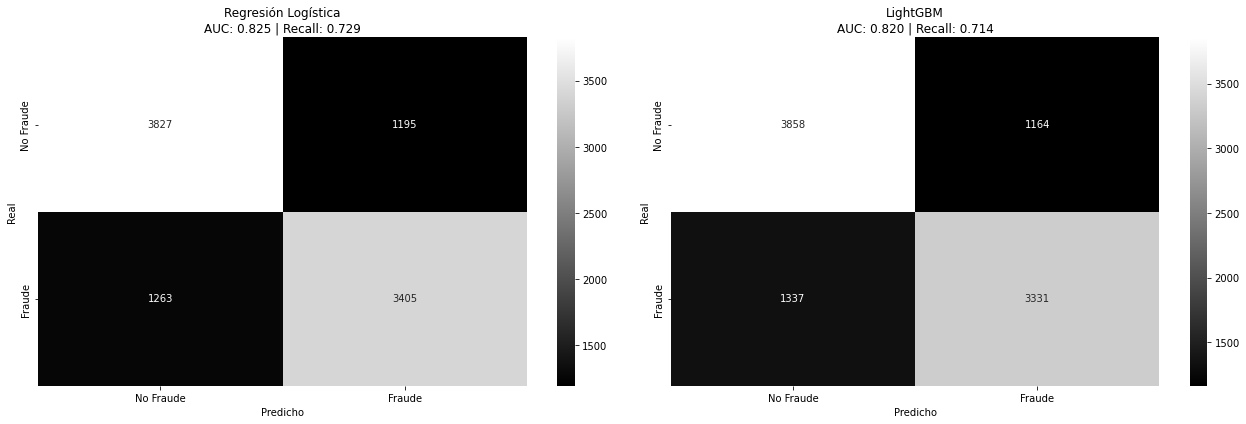


═══════════════════════════════════════════════════════════════════════════
  RECOMENDACIÓN FINAL
═══════════════════════════════════════════════════════════════════════════

 Mejor modelo: Regresión Logística
   • AUC-ROC:  0.8254
   • Recall:   0.7294  → fraudes detectados
   • F1-Score: 0.7348  → balance precisión-recall

  Para producción se prioriza el RECALL.
   El costo de un fraude no detectado supera al de una falsa alarma.
═══════════════════════════════════════════════════════════════════════════


In [56]:
# Matrices de confusión (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, res in enumerate(resultados):
    cm = confusion_matrix(y_test, res["_y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="gist_gray", ax=axes[i],
                xticklabels=["No Fraude", "Fraude"],
                yticklabels=["No Fraude", "Fraude"])
    axes[i].set_title(f"{res['Modelo']}\nAUC: {res['AUC-ROC']:.3f} | Recall: {res['Recall']:.3f}")
    axes[i].set_ylabel("Real")
    axes[i].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

# Recomendación final
print("\n" + "═" * 75)
print("  RECOMENDACIÓN FINAL")
print("═" * 75)

best   = df_resultados.iloc[0]
second = df_resultados.iloc[1]

print(f"\n Mejor modelo: {best['Modelo']}")
print(f"   • AUC-ROC:  {best['AUC-ROC']:.4f}")
print(f"   • Recall:   {best['Recall']:.4f}  → fraudes detectados")
print(f"   • F1-Score: {best['F1']:.4f}  → balance precisión-recall")

print("\n  Para producción se prioriza el RECALL.")
print("   El costo de un fraude no detectado supera al de una falsa alarma.")
print("═" * 75)

Ambos modelos fueron evaluados utilizando un umbral de clasificación de 0,50, con el objetivo de realizar una comparación homogénea de su desempeño. Una vez identificado el modelo con mejores resultados, el siguiente paso consiste en optimizar su umbral de decisión, buscando el valor que permita maximizar la capacidad de detección de fraudes y lograr el mejor equilibrio entre fraudes detectados y falsas alarmas.


In [57]:
import shap

explainer = shap.TreeExplainer(modelo_lgbm)
shap_values = explainer(X_test)

print(f"Shape SHAP values: {shap_values.shape}")  # debe ser (n_samples, n_features)

Shape SHAP values: (9690, 14)


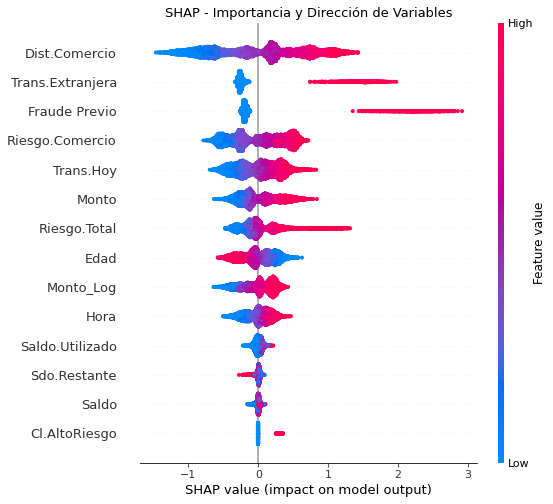

In [58]:
plt.figure(figsize=(18, 7))
shap.summary_plot(
    shap_values,   # sin [:, :, 1]
    X_test,
    plot_type="dot",
    show=False
)
plt.title("SHAP - Importancia y Dirección de Variables", fontsize=13)
plt.tight_layout()
plt.show()

- Cada punto representa una observación.  
- El eje X muestra el valor SHAP:  
Derecha (+): aumenta la probabilidad de fraude.  
Izquierda (-): disminuye la probabilidad de fraude.  
- El color indica el valor de la variable:  
Azul = valor bajo.  
Rosa/Rojo = valor alto.  
- Las variables están ordenadas por importancia global (de arriba hacia abajo)

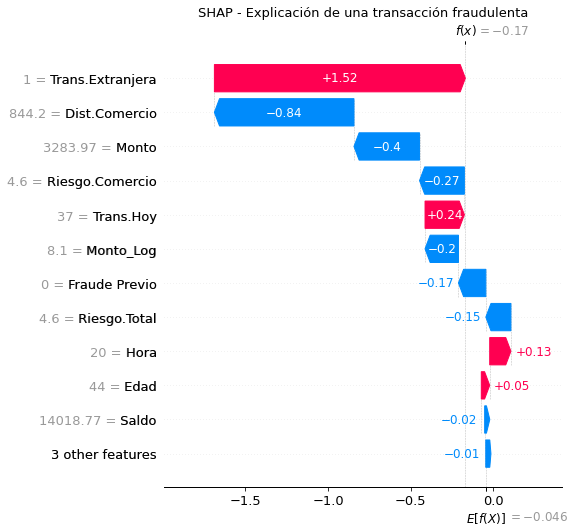

In [59]:
idx_fraude = y_test[y_test == 1].index[0]
pos = X_test.index.get_loc(idx_fraude)

shap.plots.waterfall(
    shap_values[pos],   # sin [:, 1]
    max_display=12,
    show=False
)
plt.title("SHAP - Explicación de una transacción fraudulenta", fontsize=13)
plt.tight_layout()
plt.show()

Rojo: variables que empujan la predicción hacia fraude (aportan evidencias a favor del fraude).
Azul: variables que empujan la predicción hacia no fraude.
El tamaño de la barra indica la fuerza de la contribución.

La principal evidencia de fraude proviene del carácter internacional de la operación (Trans.Extranjera = 1), que aporta la mayor contribución positiva a la predicción. Sin embargo, variables como la distancia al comercio, el monto de la transacción y el riesgo histórico del comercio ejercen una influencia negativa significativa, compensando parcialmente dicha señal. Esto indica que la decisión final del modelo surge de la combinación de múltiples factores y no de una única variable aislada

<div style="
    margin-top:40px;
    padding:16px;
    border-radius:12px;
    background:linear-gradient(90deg,#0B1220,#111827);
    border-left:4px solid #F59E0B;
    color:#E5E7EB;
    font-size:13px;
    line-height:1.6;
">
<div style="font-weight:600; font-size:14px;">
Néstor Díaz
</div>

<div style="color:#94A3B8;">
Contador Público · Data Analyst · Machine Learning
</div>

<div style="margin-top:8px; color:#F59E0B;">
Proyecto: Regresión Logistica como Benchmark y prueba de LightGBM..
</div>
</div>